In [3]:
using JuMP, Ipopt, Plots, QuadGK

In [15]:
# Constants
const L = 5000.0; # Total path length (m)
const E_budget = 2500.0; # Total energy budget (Wh)
const u_min = 0.0; # Minimum speed (m/s)
const u_max = 2.5; # Maximum speed (m/s)
const kh = 10.0; # Hotel load (W)
const km= 83.0; # Motor load coefficient (W/(m/s)^2)
const alpha = 0.4; # Clarity decay rate

N_vals = [10, 20, 50, 100, 200, 500, 1000];

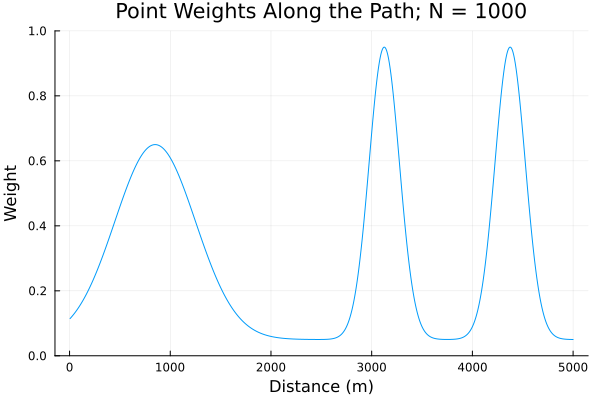

In [25]:
# Define point weights at each location
# Define point weights at each location
function point_weight(s)
    # Normalize s to range [0, 1]
    s_norm = s / L
    
    # High weight in first third (0 to 1/3)
    first_third = 0.6 * exp(-((s_norm - 0.17)^2) / (2 * 0.08^2))
    
    # High weight around 5/8
    peak_5_8 = 0.9 * exp(-((s_norm - 0.625)^2) / (2 * 0.03^2))
    
    # High weight around 7/8
    peak_7_8 = 0.9 * exp(-((s_norm - 0.875)^2) / (2 * 0.03^2))
    
    return 0.05 + first_third + peak_5_8 + peak_7_8
end

# Create a dictionary to store point locations and weights for each N
point_data = Dict()

for N in N_vals
    point_locations = [L * i / N for i in 1:N]
    point_weights = [point_weight(loc) for loc in point_locations]
    point_data[N] = Dict("locations" => point_locations, "weights" => point_weights)
end

n_vals_idx = 7;
plot(point_data[N_vals[n_vals_idx]]["locations"], point_data[N_vals[n_vals_idx]]["weights"], label=false, xlabel="Distance (m)", ylabel="Weight", title="Point Weights Along the Path; N = $(N_vals[n_vals_idx])", legend=false)
ylims!(0, 1)